In [216]:
import yfinance as yf
import pandas as pd
import numpy as np
from tensorflow import keras
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from sklearn.metrics import mean_absolute_percentage_error

In [217]:
def get_live_data(ticker: str) -> tuple[pd.DataFrame, datetime]:
    data = yf.download(ticker, period="1d", interval="1m", prepost=True, progress=False) 
    return (data, data.last_valid_index()) # type: ignore

In [ ]:
# Load current data for all tickers
tickers = [
    "AAPL", "ADBE", "MSFT", "GOOG", "AMZN",
    "TSLA", "NVDA", "META", "AMD", "INTC",
    "MU", "ARM", "TXN", "QCOM", "STX",
    "WDC", "SHOP", "ORCL", "AVGO", "CRWD",
    "RDDT"
]
data = [get_live_data(ticker) for ticker in tickers]

In [ ]:
# Format and normalize data for model
input_data = []
unnorm_input_data = []
means = []
offset = 0 # Set to higher value to use earlier data (prediction payoff comes earlier)
for (ticker_data, last_time) in data:
    mean = ticker_data["Open"].mean().iloc[0] #type: ignore
    means.append(mean)
    opens = ticker_data.sort_index().iloc[offset:offset+46]["Open"]
    input_data.append(np.log(opens / mean).to_numpy()[np.newaxis, ...])
    unnorm_input_data.append(opens.to_numpy().transpose()[0])
    ntime = last_time + timedelta(minutes=15-offset)
input_data = np.concatenate(input_data)
input_data.shape

(21, 46, 1)

In [ ]:
# Load model and make/denormalize predictions
model = keras.models.load_model("model1.keras")
norm_predictions = model.predict(input_data)
predictions = (np.exp(norm_predictions).transpose() * means)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step


In [ ]:
def plot_ticker(ticker: str, data: list[float], prediction: float, real: float | None):
    steps = range(15,61)
    pairs = [(val, -step) for (val, step) in zip(data, reversed(steps))]
    pairs.sort(key=lambda p: p[1])

    x = [t for (_, t) in pairs]
    y = [v for (v, _) in pairs]

    (last_y, last_x) = pairs[-1]

    plt.figure()
    plt.plot(x, y)
    plt.plot([0, last_x], [prediction, last_y], 'r--', label="Predicted")
    plt.title(ticker)
    if real is not None:
        plt.plot([0, last_x], [real, last_y], 'b--', label="Actual")
    plt.legend()
    plt.show()

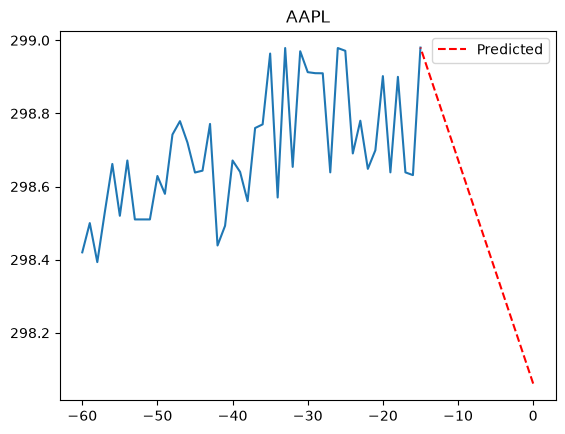

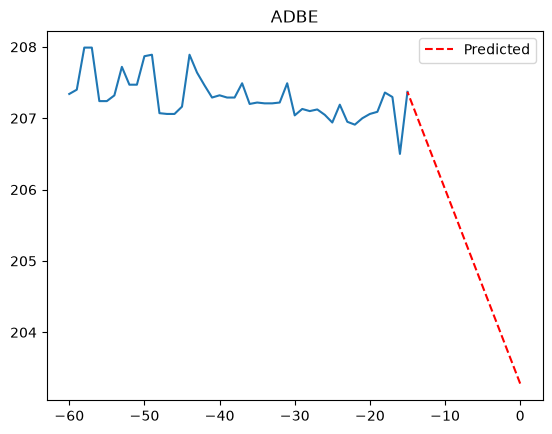

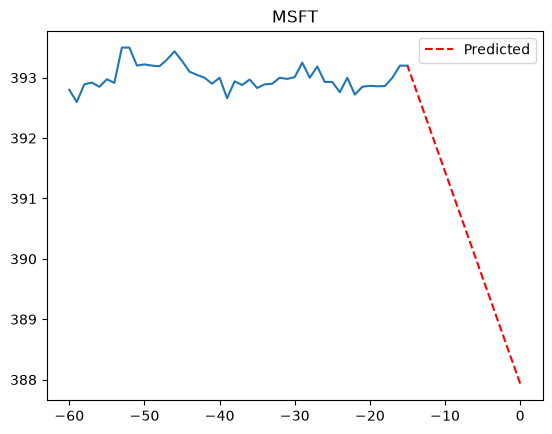

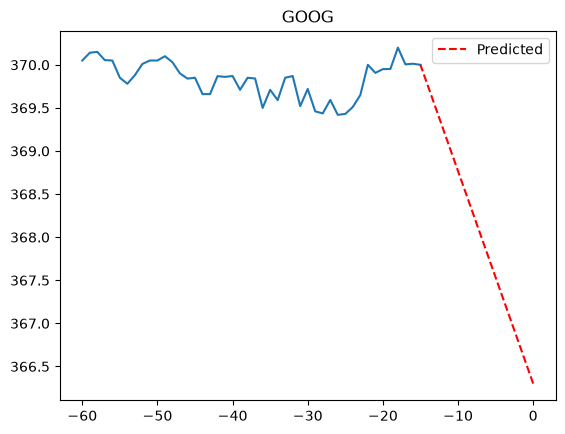

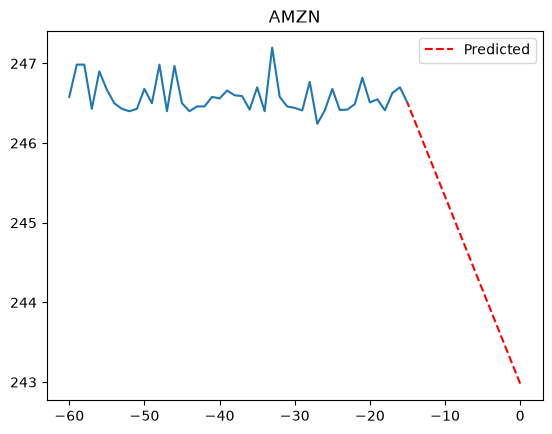

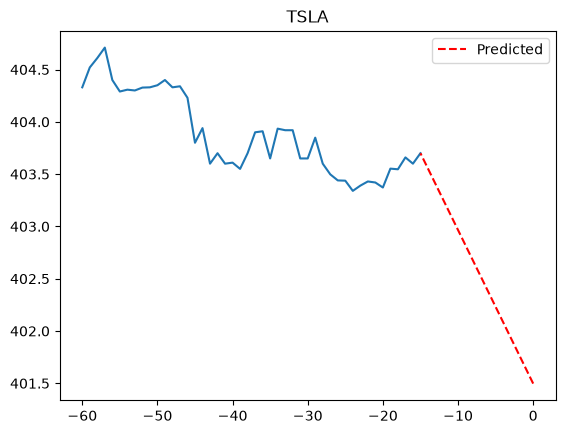

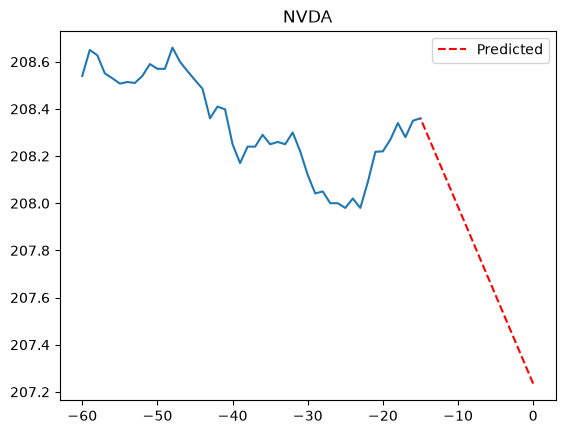

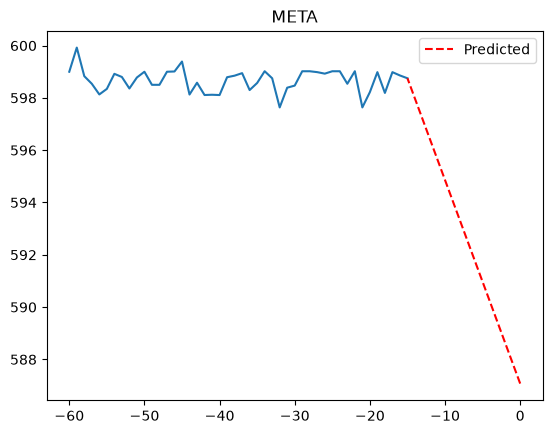

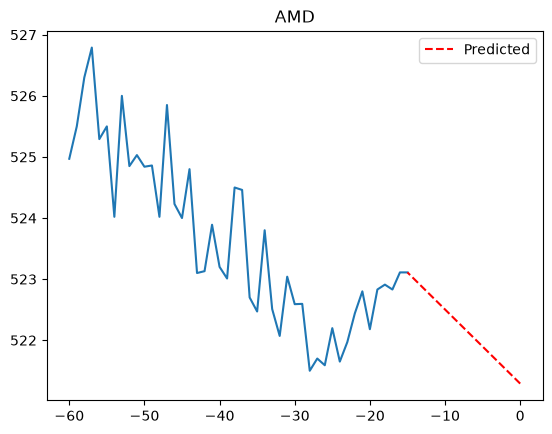

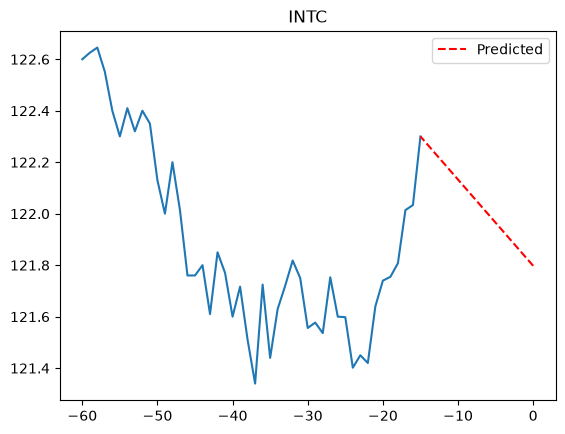

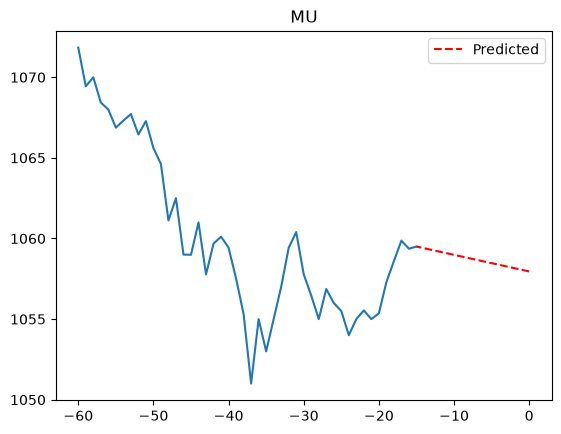

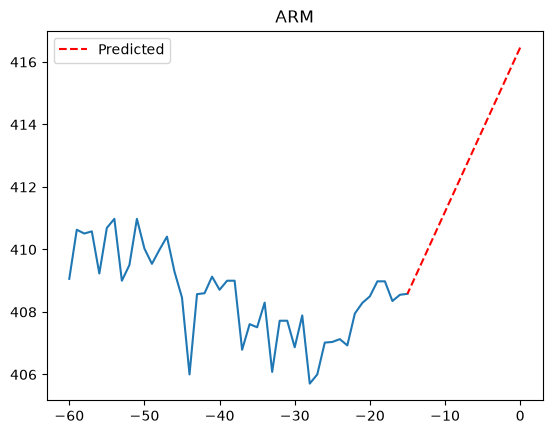

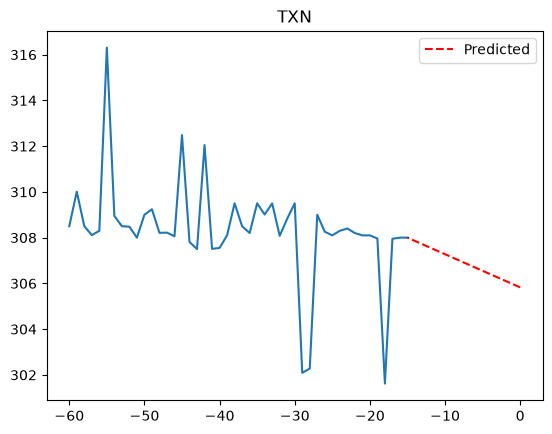

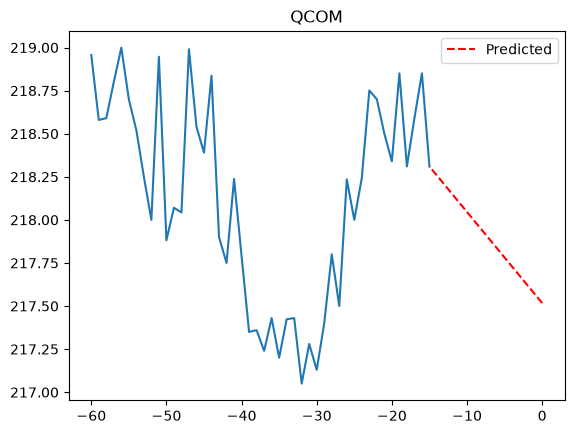

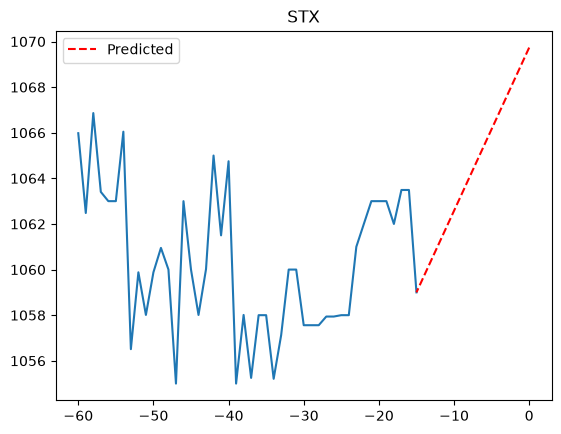

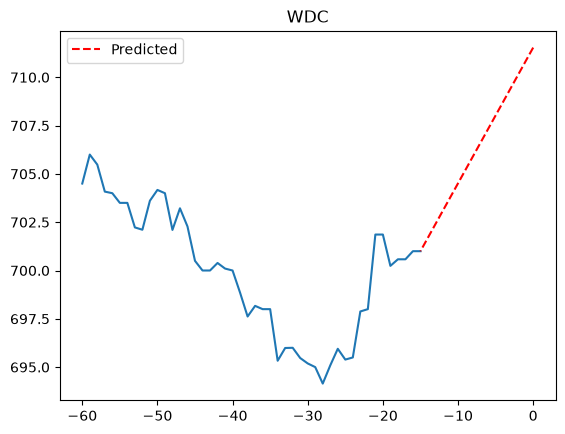

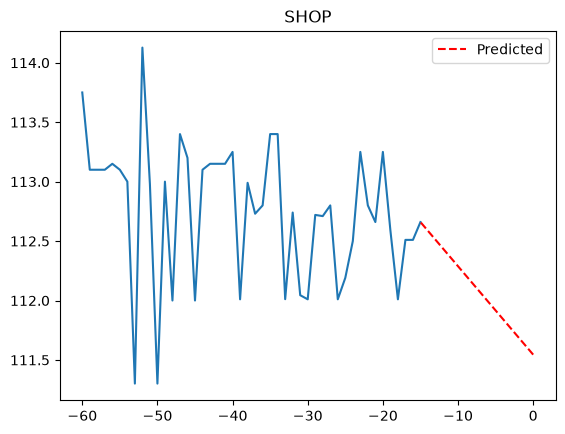

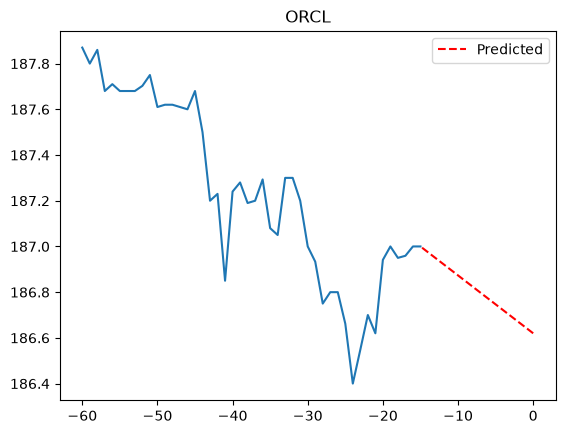

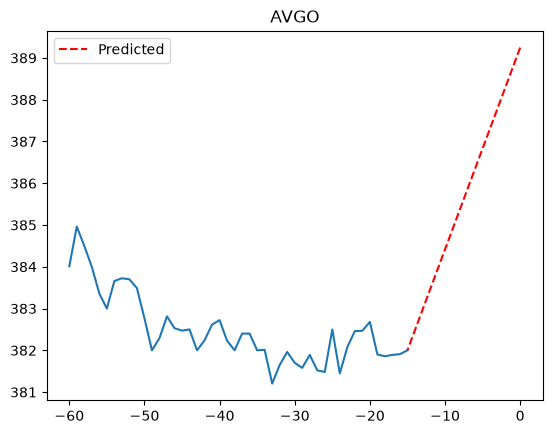

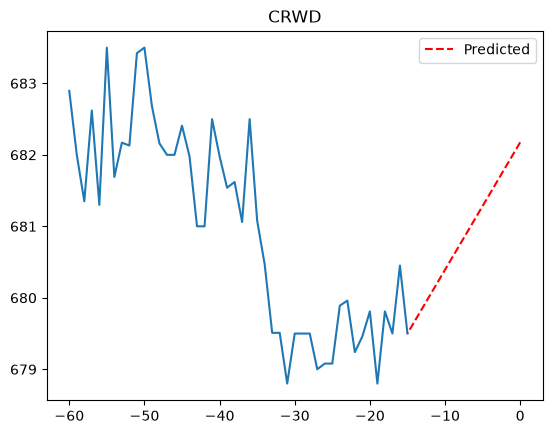

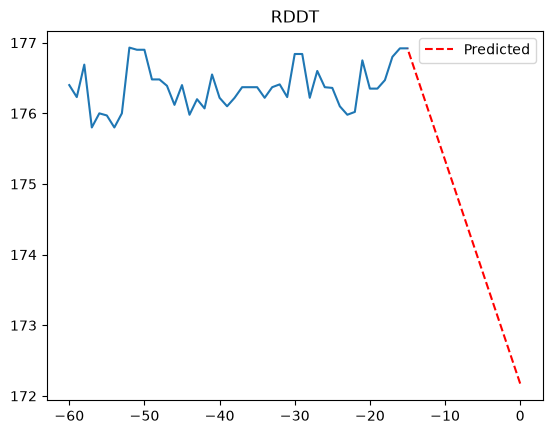

In [ ]:
# Plot all tickers while waiting for actual prices
for idx, ticker in enumerate(tickers):
    plot_ticker(ticker, unnorm_input_data[idx], predictions[idx], None)

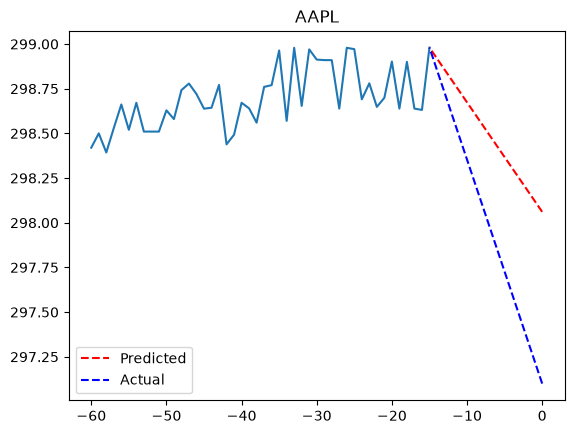

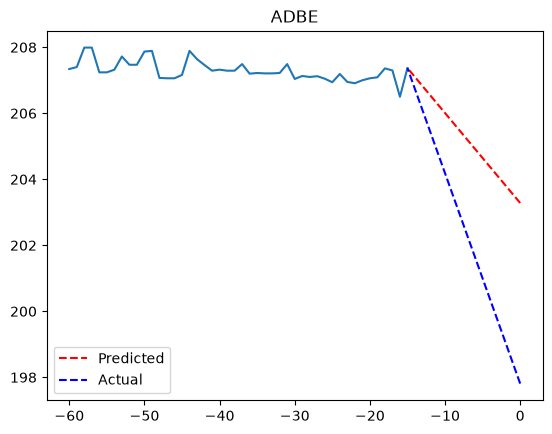

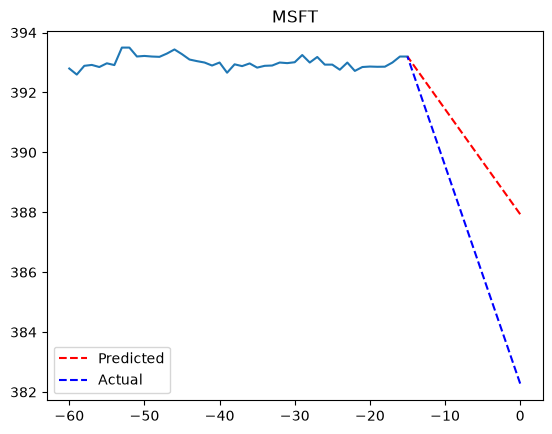

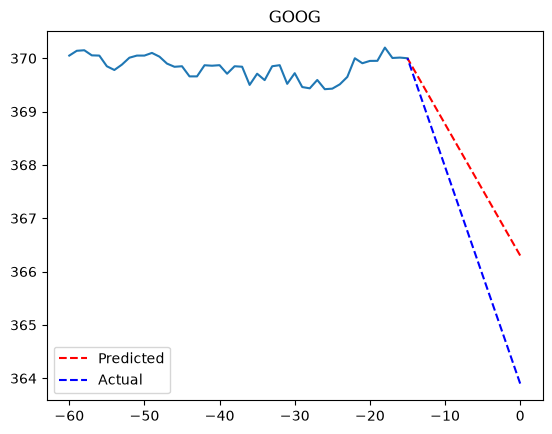

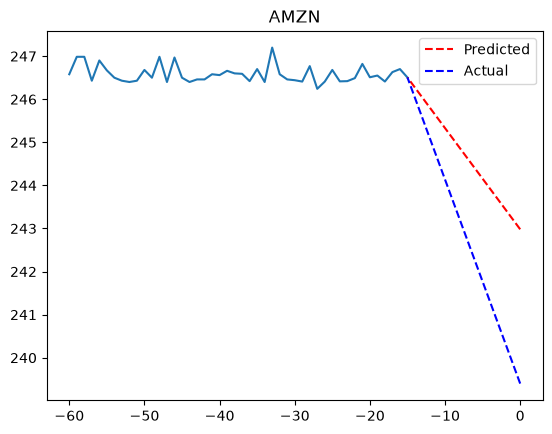

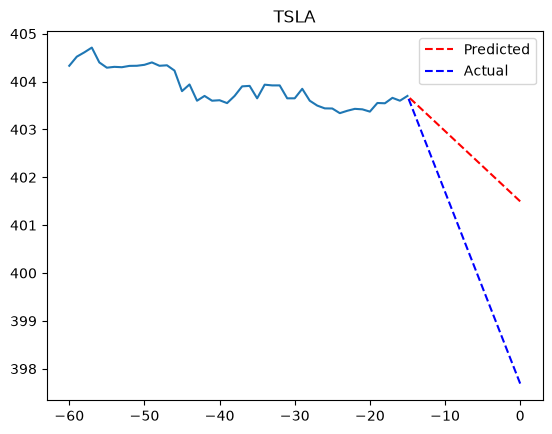

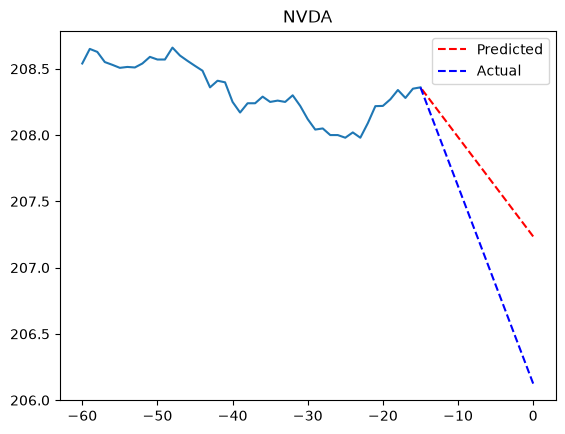

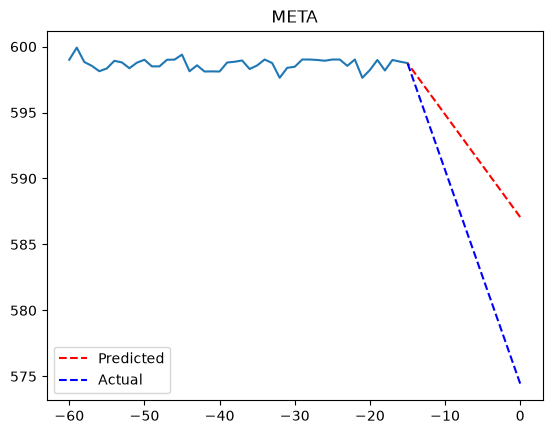

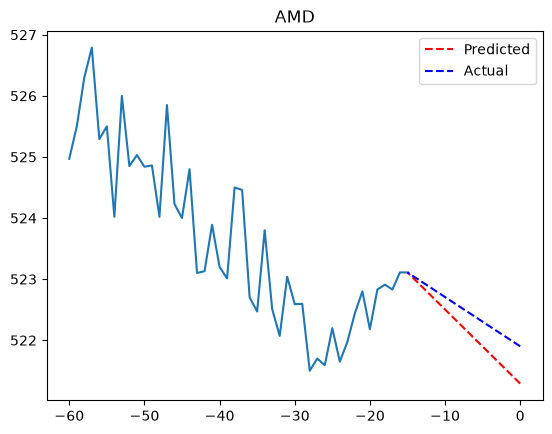

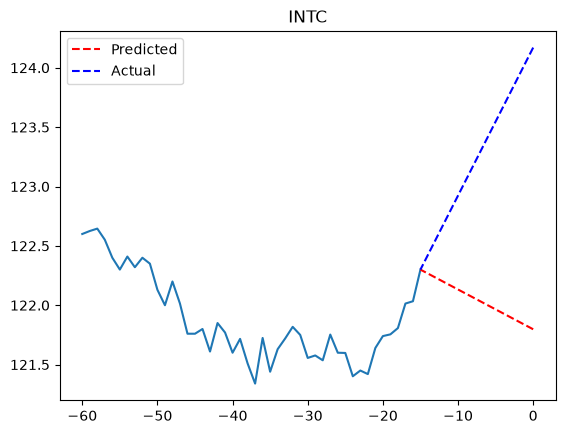

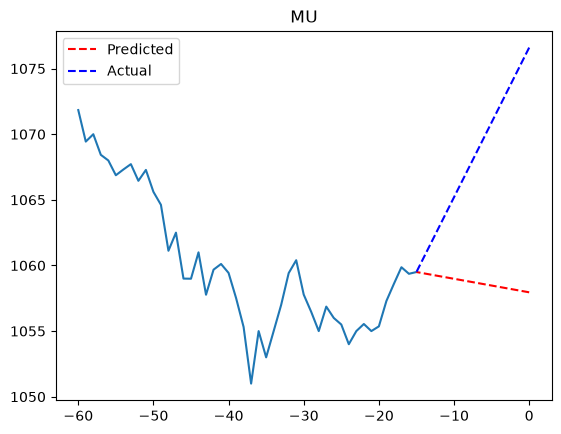

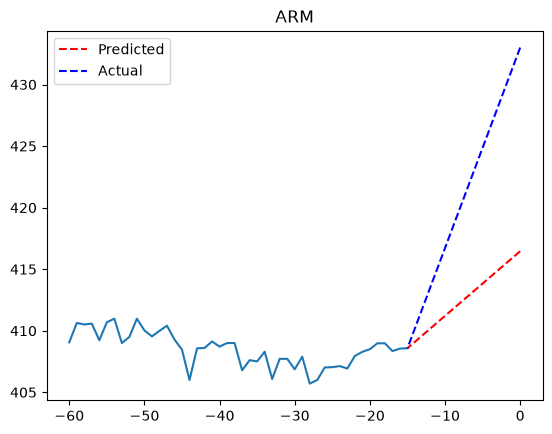

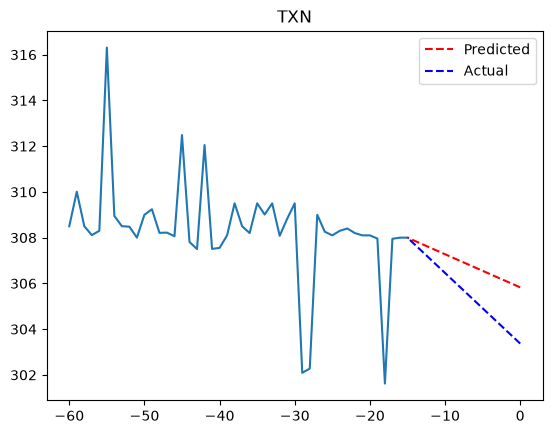

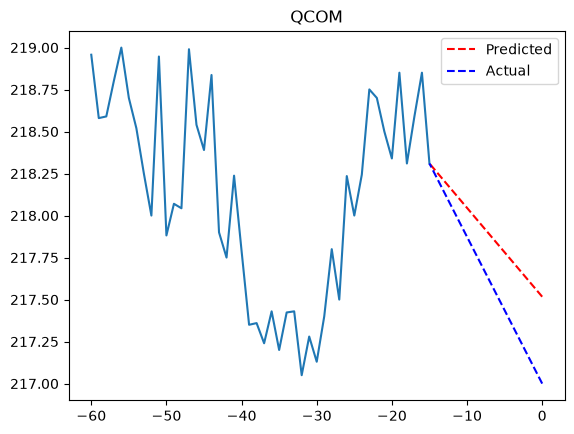

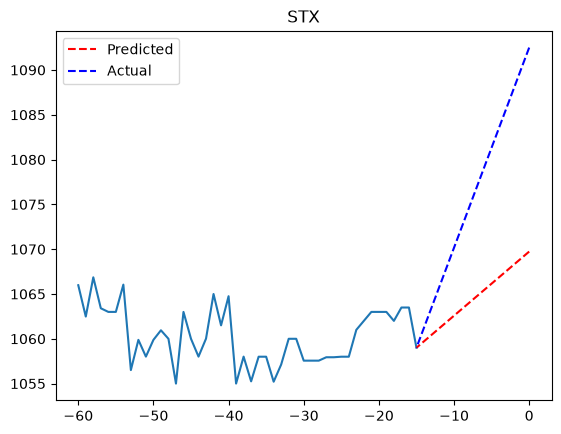

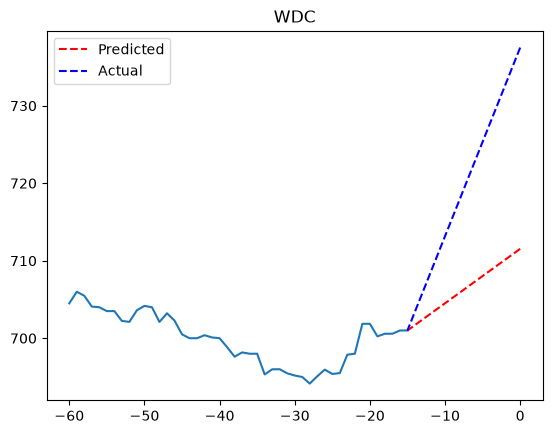

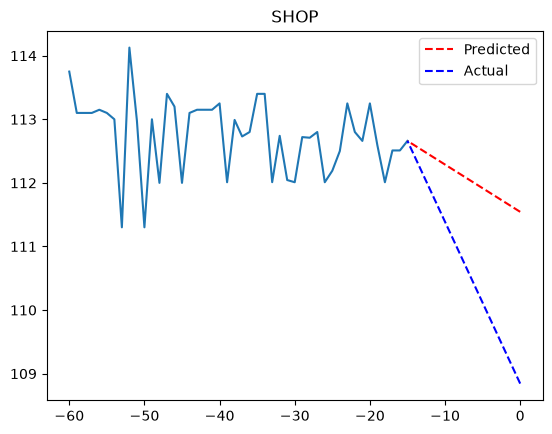

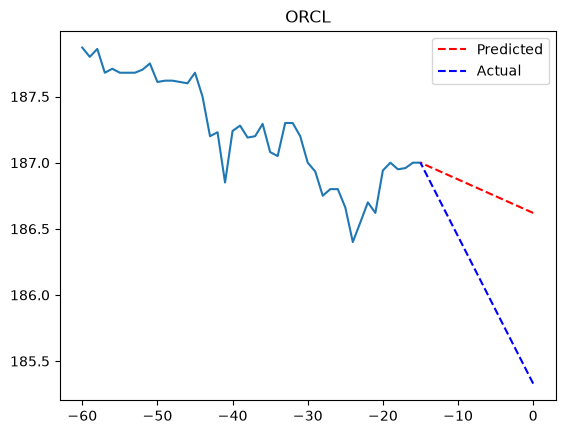

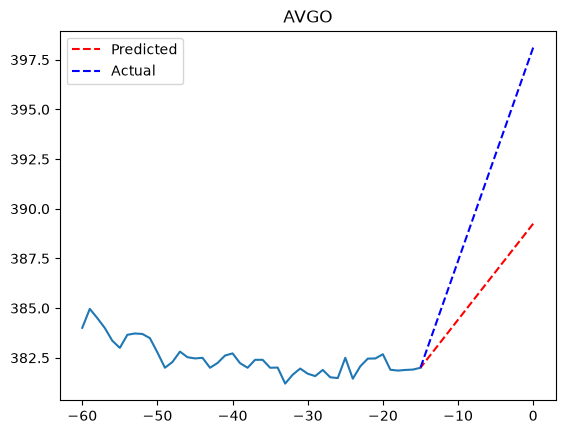

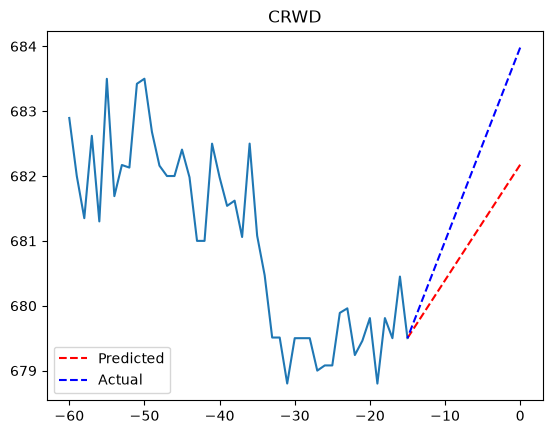

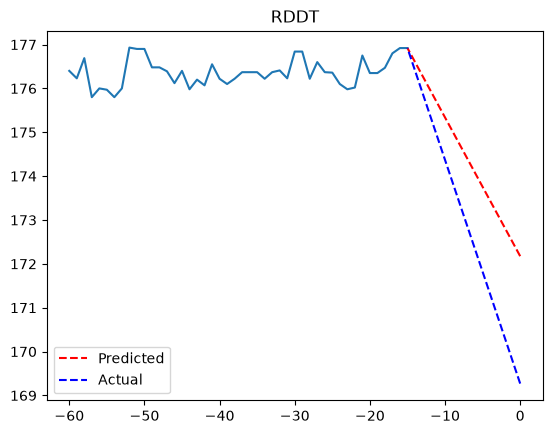

In [ ]:
# Wait for price data to come in
if datetime.now().timestamp() <= ntime.timestamp():
    print("need to wait for", ntime)
else:
    # Retrieve prices from the predicted time and add them to the plot
    current_prices = []
    for ticker in tickers:
        live, _ = get_live_data(ticker)
        ntime_idx = live.index.get_indexer([ntime], method="nearest")[0] #type: ignore
        current_prices.append(live["Open"].iloc[ntime_idx].iloc[0])
    for idx, ticker in enumerate(tickers):
        plot_ticker(ticker, unnorm_input_data[idx], predictions[idx], current_prices[idx])

In [225]:
last = [u[-1] for u in unnorm_input_data]
mean_absolute_percentage_error(predictions - last, np.array(current_prices) - last)

2.0398491652583006